<a href="https://colab.research.google.com/github/Sakshamg0126/ArtExtract--GSoc26/blob/main/ArtExtract_using_Efficientnet_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
import os

In [55]:
!pip install -q kaggle

In [56]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"sakshamgurrap","key":"444957462da78a9458faa85cc3613499"}'}

In [57]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [58]:
!kaggle datasets download -d lgmoneda/rijksmuseum --unzip -p /content/rijksmuseum_data

Dataset URL: https://www.kaggle.com/datasets/lgmoneda/rijksmuseum
License(s): ODbL-1.0
100% 4.99G/4.99G [01:14<00:00, 72.0MB/s]



In [59]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from pathlib import Path
from PIL import Image


Dataset ready! Learning 4 Types and 4202 Artists.
✅ Core Pipeline Initialized. Model is ready in memory!


# 1. LOAD AND CLEAN METADATA


In [86]:
data_dir = Path("/content/rijksmuseum_data/rijksmuseum")
csv_path = data_dir / "metadata.csv"
image_folder = data_dir / "images"

# Load CSV and drop rows missing critical data
df = pd.read_csv(csv_path)
df = df.dropna(subset=['id', 'artist', 'type']).copy()

# 2. ENCODE TEXT LABELS TO NUMBERS


In [87]:
artist_encoder = LabelEncoder()
type_encoder = LabelEncoder()

df['artist_label'] = artist_encoder.fit_transform(df['artist'])
df['type_label'] = type_encoder.fit_transform(df['type'])

num_artists = len(artist_encoder.classes_)
num_types = len(type_encoder.classes_)

print(f"Dataset ready! Learning {num_types} Types and {num_artists} Artists.")

Dataset ready! Learning 4 Types and 4202 Artists.


# 3. CUSTOM PYTORCH DATASET

In [88]:
class RijksmuseumDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = f"{row['id']}.jpg"
        img_path = self.image_dir / img_name

        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            image = Image.new('RGB', (224, 224), color='black')

        if self.transform:
            image_tensor = self.transform(image)
        else:
            image_tensor = image

        artist_target = torch.tensor(row['artist_label'], dtype=torch.long)
        type_target = torch.tensor(row['type_label'], dtype=torch.long)

        return image_tensor, artist_target, type_target

# 4. BUILD THE MULTI-TASK EFFICIENTNET

In [81]:
class RijksmuseumNet(nn.Module):
    def __init__(self, num_types, num_artists):
        super().__init__()
        self.backbone = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)

        feature_dim = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        self.type_head = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_types)
        )

        self.artist_head = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_artists)
        )

    def forward(self, x):
        features = self.backbone(x)
        type_pred = self.type_head(features)
        artist_pred = self.artist_head(features)
        return type_pred, artist_pred

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = RijksmuseumNet(num_types=num_types, num_artists=num_artists).to(DEVICE)
print("✅ Core Pipeline Initialized. Model is ready in memory!")

✅ Core Pipeline Initialized. Model is ready in memory!


In [68]:
import torch
from torchvision import transforms
from PIL import Image
from google.colab import files
import io
import matplotlib.pyplot as plt

# 5. Define standard evaluation transforms

In [72]:
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 6. Prediction Function


In [73]:
def predict_artwork(image_bytes, trained_model, transform, artist_enc, type_enc, device):
    trained_model.eval()

    # Load and show image
    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.title("Uploaded Artwork")
    plt.show()

    # Process image
    img_tensor = transform(image).unsqueeze(0).to(device)

    # Predict
    with torch.inference_mode():
        out_type, out_artist = trained_model(img_tensor)
        type_idx = out_type.argmax(dim=1).item()
        artist_idx = out_artist.argmax(dim=1).item()

    # Decode
    pred_type = type_enc.inverse_transform([type_idx])[0]
    pred_artist = artist_enc.inverse_transform([artist_idx])[0]

    return pred_artist, pred_type

# 7. Interactive Upload


📤 Upload an artwork image to get its metadata!


Saving SK-A-3748.jpg to SK-A-3748.jpg

Processing 'SK-A-3748.jpg'...


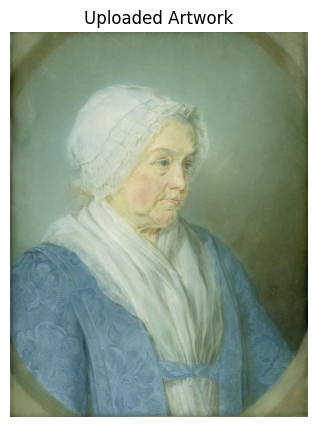

----------------------------------------
🎯 PREDICTION RESULTS
----------------------------------------
Predicted Artist:  Jean-Baptiste Oudry
Predicted Type:    photomechanical print
----------------------------------------


In [95]:
print("📤 Upload an artwork image to get its metadata!")
uploaded = files.upload()
for filename, content in uploaded.items():
    print(f"\nProcessing '{filename}'...")

    # Catch ALL 6 values being returned by the function
    artist, art_type, top_score, mean_score, mean_dev, ent_loss = predict_artwork(
        image_bytes=content,
        trained_model=model,
        transform=inference_transform,
        artist_enc=artist_encoder,
        type_enc=type_encoder,
        device=DEVICE
    )

    print("-" * 40)
    print("🎯 PREDICTION RESULTS")
    print("-" * 40)
    print(f"Predicted Artist:  {artist}")
    print(f"Predicted Type:    {art_type}")
    print("-" * 40)